# Question 2: Parametric PODNN for Navier-Stokes

This notebook follows the same first stages as `Q1.ipynb`: build the FEM full order model, generate FOM snapshots, and construct POD spaces for velocity and pressure. The difference is the online stage: instead of solving the reduced Navier-Stokes equations with POD-Galerkin, we train a feed-forward neural network to predict the POD coefficients directly from the parameters $(\mu_0, \mu_1)$.


In [47]:
#Mount Colab to Google Drive to save and share files
from google.colab import drive
import os
drive.mount('/content/drive')
%cd /content/drive/MyDrive/MOR-project
!ls

!python3 -m pip install vtk
!python3 -m pip install pypolydim
import numpy as np
import argparse
import os.path
import scipy.sparse
import scipy.linalg
import vtk
import matplotlib.pyplot as plt
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
#import sys
#sys.path.insert(0, "/content/drive/MyDrive/MOR-project")
import other_utilities as other_ut



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MOR-project
Export	Meshes	other_utilities.py  __pycache__  Q1.ipynb


In [48]:
#Initalize parameters
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

#All export folders path
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

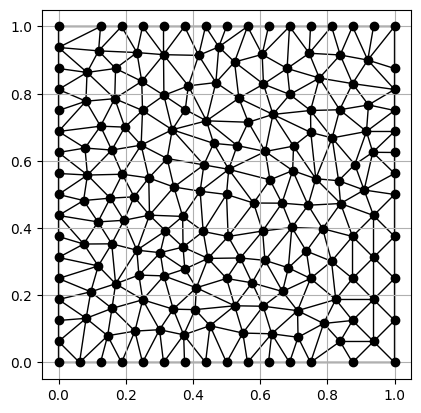

In [49]:
#Define the domain [0,1]x[0,1]
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

#Define the mesh
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular 
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc     
method_order = 1
mesh_size = 0.005

mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

#plot the mesh
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [50]:
print("Vertex markers:", np.unique(mesh_data.cell0_d_markers))
print("Edge markers:", np.unique(mesh_data.cell1_d_markers))

Vertex markers: [0 1 2 3 4 5 6 7 8]
Edge markers: [0 5 6 7 8]


In [51]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet, #fix pressure at (0,0) to 0
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [52]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [53]:
#amount of DOF's

pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
181 	 1 	 557 	 112 	 1295 	 225


In [54]:
#assemble the FEM matrices
def pressure_strong_function(marker, x, y, z):
    return 0.0

def speed_x_strong_function(marker, x, y, z):
    return 0.0

def speed_y_strong_function(marker, x, y, z):
    return 0.0

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_mesh_dofs_info,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_strong_function
)

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_x_strong_function
)

u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_y_strong_function
)

strong_solution = np.concatenate([u_x_strong, u_y_strong, p_strong])

In [55]:
#check the dimensions 

print("strong_solution shape:", strong_solution.shape)

print("speed_n_dofs:", speed_n_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("total expected:", 2 * speed_n_dofs + pressure_n_dofs)

strong_solution shape: (225,)
speed_n_dofs: 557
pressure_n_dofs: 181
total expected: 1295


In [56]:
def one_term(x, y, z):  
    return 1.0

def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])


A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

A_speed = other_ut.make_np_sparse(A_operator.operator_dofs)

J_A_x = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [0, 0]
)

J_A_y = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [speed_n_dofs, speed_n_dofs]
)

J_A_Base = J_A_x + J_A_y

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_B = -J_B_x - J_B_y - J_BT_x - J_BT_y

# Velocity mass matrix: int u v dx
M_speed_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

M_speed = other_ut.make_np_sparse(M_speed_operator.operator_dofs)

# Velocity H1 inner product:
# ||u||^2 + ||grad u||^2 for both u_x and u_y
X_u = scipy.sparse.block_diag(
    [A_speed + M_speed, A_speed + M_speed],
    format="csr"
)

# Pressure mass matrix: int p q dx
M_p_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_dofs_data,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_reference_element_data,
    one_term
)

M_p = other_ut.make_np_sparse(M_p_operator.operator_dofs)

# Pressure L2 inner product
X_p = M_p

print("A_speed shape:", A_speed.shape)
print("M_speed shape:", M_speed.shape)
print("X_u shape:", X_u.shape)
print("X_p shape:", X_p.shape)

A_speed shape: (557, 557)
M_speed shape: (557, 557)
X_u shape: (1114, 1114)
X_p shape: (181, 181)


In [57]:
def assemble_source(mu1):
    def f_1_function(x, y, z):
        return -(
            mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * x)
            - mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * y) * np.cos(mu1 * np.pi * y) \
        + mu1 * np.pi * np.cos(mu1 * np.pi * x) * np.cos(mu1 * np.pi * y)

    def f_2_function(x, y, z):
        return -(
            -mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * y)
            + mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * x) * np.cos(mu1 * np.pi * x) \
        - mu1 * np.pi * np.sin(mu1 * np.pi * x) * np.sin(mu1 * np.pi * y)

    f_1 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_1_function
    )

    f_2 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_2_function
    )

    f_S = np.concatenate([
        f_1,
        f_2,
        np.zeros(pressure_n_dofs)
    ])

    return f_S

def assemble_stokes_matrix(mu0):
    J_S = mu0 * J_A_Base + J_B
    return J_S


In [58]:
#use same seed for now
np.random.seed(1)

mu0_range = [0.1, 10.0]
mu1_range = [1.0, 3.0]
P = np.array([mu0_range, mu1_range])

num_uniform = 300
num_low_mu0 = 250
num_edges = 100

# Random samples over the full domain
training_uniform = np.random.uniform(
    low=P[:, 0],
    high=P[:, 1],
    size=(num_uniform, P.shape[0])
)

# Extra samples near the low-viscosity region.
training_low_mu0 = np.column_stack([
    np.random.uniform(0.1, 1.0, size=num_low_mu0),
    np.random.uniform(1.0, 3.0, size=num_low_mu0)
])

# Extra samples near mu1 edges: mu1 close to 1 and 3.
training_mu1_edges = np.column_stack([
    np.random.uniform(0.1, 10.0, size=num_edges),
    np.random.choice([1.0, 3.0], size=num_edges)
])

# Coarse grid in the low-viscosity region.
mu0_low_grid = np.array([0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0])
mu1_grid = np.linspace(1.0, 3.0, 15)

MU0_LOW, MU1_LOW = np.meshgrid(mu0_low_grid, mu1_grid, indexing="ij")
training_low_grid = np.column_stack([MU0_LOW.ravel(), MU1_LOW.ravel()])

# Dense samples on and near the difficult edge mu0 = 0.1.
mu0_near_min = np.array([0.1, 0.125, 0.15, 0.2, 0.3])
mu1_dense = np.linspace(1.0, 3.0, 31)

MU0_EDGE, MU1_EDGE = np.meshgrid(mu0_near_min, mu1_dense, indexing="ij")
training_near_mu0_min = np.column_stack([MU0_EDGE.ravel(), MU1_EDGE.ravel()])

# Extra dense line exactly at the minimum viscosity boundary.
mu1_dense_edge = np.linspace(1.0, 3.0, 41)
training_mu0_min_edge = np.column_stack([
    np.full_like(mu1_dense_edge, 0.1),
    mu1_dense_edge
])

# A few exact corner and boundary samples.
training_boundary = np.array([
    [0.1, 1.0],
    [0.1, 2.0],
    [0.1, 3.0],
    [0.2, 1.0],
    [0.2, 2.0],
    [0.2, 3.0],
    [0.5, 1.0],
    [0.5, 2.0],
    [0.5, 3.0],
    [1.0, 1.0],
    [1.0, 2.0],
    [1.0, 3.0],
    [10.0, 1.0],
    [10.0, 2.0],
    [10.0, 3.0],
])

training_set = np.vstack([
    training_uniform,
    training_low_mu0,
    training_mu1_edges,
    training_low_grid,
    training_near_mu0_min,
    training_mu0_min_edge,
    training_boundary
])

snapshot_num = training_set.shape[0]

print(training_set.shape)
print(training_set)


(966, 2)
[[ 4.22851785  2.44064899]
 [ 0.10113231  1.60466515]
 [ 1.55288332  1.18467719]
 ...
 [10.          1.        ]
 [10.          2.        ]
 [10.          3.        ]]


In [59]:

def solve_fom(mu0, mu1):
    residual_norm = 1.0
    solution_norm = 1.0
    newton_tol = 1.0e-5
    max_iterations = 10
    num_iteration = 1


    # starting guess on initial condition

    def speed_x_initial_condition(x, y, z):  
        return 0.0

    def speed_y_initial_condition(x, y, z):  
        return 0.0

    def pressure_initial_condition(x, y, z):  
        return 0.0

    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_x_initial_condition).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_y_initial_condition).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    pressure_initial_condition).function_dofs

    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)


    #assemble and update source term with mu1
    f_S = assemble_source(mu1)

    #Update J_S with mu0
    J_S = assemble_stokes_matrix(mu0)
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_y_numeric,
            u_x_strong,
            u_y_strong
        )

        J_C = other_ut.make_np_sparse(
            c_operator.convective_operator.operator_dofs,
            [tot_dofs, tot_dofs],
            [0, 0]
        )

        f_C = np.concatenate([
            c_operator.convective_rhs,
            np.zeros(pressure_n_dofs)
        ])

        J_f = f_S - f_C - J_S @ u_k

        du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

        u_k = u_k + du

        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2 * speed_n_dofs]
        dp = du[2 * speed_n_dofs:]

        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_k[2 * speed_n_dofs:]

        du_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_x,
            du_x_strong
        )

        du_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_y,
            du_y_strong
        )

        dp_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            dp,
            dp_strong
        )

        u_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_x_strong
        )

        u_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_y_numeric,
            u_y_strong
        )

        p_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            p_numeric,
            p_strong
        )

        solution_norm = np.sqrt(
            u_x_norm_L2.numeric_norm_l2**2 +
            u_y_norm_L2.numeric_norm_l2**2 +
            p_norm_L2.numeric_norm_l2**2
        )

        residual_norm = np.sqrt(
            du_x_norm_L2.numeric_norm_l2**2 +
            du_y_norm_L2.numeric_norm_l2**2 +
            dp_norm_L2.numeric_norm_l2**2
        )
                
        num_iteration = num_iteration + 1


    info = {
        "mu0": mu0,
        "mu1": mu1,
        "iterations": num_iteration - 1,
        "final_ratio": residual_norm / solution_norm,
        "converged": residual_norm <= newton_tol * solution_norm
    }

    return u_k, u_x_numeric, u_y_numeric, p_numeric, info
    

In [60]:
snapshot_matrix = []
info_list = []

for i, mu in enumerate(training_set):
    mu0 = mu[0]
    mu1 = mu[1]

    print(f"Snapshot {i+1}/{snapshot_num}: mu0={mu0:.4f}, mu1={mu1:.4f}")

    u_k, u_x_numeric, u_y_numeric, p_numeric, info = solve_fom(mu0, mu1)

    snapshot_matrix.append(np.copy(u_k))
    info_list.append(info)

snapshot_matrix = np.array(snapshot_matrix)

S_u = snapshot_matrix[:, :2 * speed_n_dofs]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]

print("S_u shape:", S_u.shape)
print("S_p shape:", S_p.shape)


Snapshot 1/966: mu0=4.2285, mu1=2.4406
Snapshot 2/966: mu0=0.1011, mu1=1.6047
Snapshot 3/966: mu0=1.5529, mu1=1.1847
Snapshot 4/966: mu0=1.9440, mu1=1.6911
Snapshot 5/966: mu0=4.0280, mu1=2.0776
Snapshot 6/966: mu0=4.2500, mu1=2.3704
Snapshot 7/966: mu0=2.1241, mu1=2.7562
Snapshot 8/966: mu0=0.3711, mu1=2.3409
Snapshot 9/966: mu0=4.2313, mu1=2.1174
Snapshot 10/966: mu0=1.4898, mu1=1.3962
Snapshot 11/966: mu0=8.0274, mu1=2.9365
Snapshot 12/966: mu0=3.2029, mu1=2.3846
Snapshot 13/966: mu0=8.7763, mu1=2.7892
Snapshot 14/966: mu0=0.9419, mu1=1.0781
Snapshot 15/966: mu0=1.7813, mu1=2.7563
Snapshot 16/966: mu0=1.0736, mu1=1.8422
Snapshot 17/966: mu0=9.5831, mu1=2.0663
Snapshot 18/966: mu0=6.9496, mu1=1.6310
Snapshot 19/966: mu0=6.8964, mu1=2.6693
Snapshot 20/966: mu0=0.2811, mu1=2.5003
Snapshot 21/966: mu0=9.8897, mu1=2.4963
Snapshot 22/966: mu0=2.8764, mu1=2.5786
Snapshot 23/966: mu0=1.1219, mu1=1.8958
Snapshot 24/966: mu0=9.0951, mu1=1.5872
Snapshot 25/966: mu0=2.9490, mu1=1.2601
Snapshot 

In [61]:
# Pressure-to-velocity coupling block
BT = J_B[:2 * speed_n_dofs, 2 * speed_n_dofs:]

print("BT shape:", BT.shape)
print("X_u shape:", X_u.shape)

snapshot_matrix_s = []

for i in range(S_p.shape[0]):
    snapshot_p = S_p[i, :]

    rhs_s = BT @ snapshot_p

    snapshot_s = scipy.sparse.linalg.spsolve(X_u, rhs_s)

    snapshot_matrix_s.append(np.copy(snapshot_s))

snapshot_matrix_s = np.array(snapshot_matrix_s)

print("snapshot_matrix_s shape:", snapshot_matrix_s.shape)

BT shape: (1114, 181)
X_u shape: (1114, 1114)
snapshot_matrix_s shape: (966, 1114)


In [62]:
print("snapshot_matrix shape:", snapshot_matrix.shape)
#check snapshot matrix same shape as total dofs x num. training
print("total DOF's:", tot_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("pressure_n_strongs:", pressure_n_strongs)
print("speed_n_dofs:", speed_n_dofs)
print("speed_n_strongs:", speed_n_strongs)


snapshot_matrix shape: (966, 1295)
total DOF's: 1295
pressure_n_dofs: 181
pressure_n_strongs: 1
speed_n_dofs: 557
speed_n_strongs: 112


In [63]:
def build_pod_basis_from_snapshots(S, inner_product):
    C = S @ inner_product @ S.T
    tol = 0.9999
    eigenvalues, eigenvectors = np.linalg.eigh(C)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    eigenvalues = np.maximum(eigenvalues, 0.0)

    total_energy = np.sum(eigenvalues)
    relative_retained_energy = np.cumsum(eigenvalues) / total_energy

    N = np.argmax(relative_retained_energy >= tol) + 1

    basis_functions = []

    for n in range(N):
        eigenvector = eigenvectors[:, n]

        basis = S.T @ eigenvector

        norm = np.sqrt(basis.T @ inner_product @ basis)

        if norm < 1e-14:
            print(f"Skipping mode {n}: norm too small")
            continue

        basis /= norm
        basis_functions.append(np.copy(basis))

    basis_functions = np.array(basis_functions).T

    return basis_functions, eigenvalues, relative_retained_energy, N

In [64]:
V_u, eig_u, energy_u, N_u = build_pod_basis_from_snapshots(S_u, X_u)

V_p, eig_p, energy_p, N_p = build_pod_basis_from_snapshots(S_p, X_p)

V_s, eig_s, energy_s, N_s = build_pod_basis_from_snapshots(snapshot_matrix_s, X_u)

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("N_u:", N_u)
print("N_p:", N_p)

G_u = V_u.T @ X_u @ V_u
G_p = V_p.T @ X_p @ V_p

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("V_s shape:", V_s.shape)

print("N_u:", N_u)
print("N_p:", N_p)
print("N_s:", N_s)

print("Velocity orthonormality error:",
      np.linalg.norm(V_u.T @ X_u @ V_u - np.eye(V_u.shape[1])))

print("Pressure orthonormality error:",
      np.linalg.norm(V_p.T @ X_p @ V_p - np.eye(V_p.shape[1])))

print("Supremizer orthonormality error:",
      np.linalg.norm(V_s.T @ X_u @ V_s - np.eye(V_s.shape[1])))


V_u shape: (1114, 24)
V_p shape: (181, 28)
N_u: 24
N_p: 28
V_u shape: (1114, 24)
V_p shape: (181, 28)
V_s shape: (1114, 29)
N_u: 24
N_p: 28
N_s: 29
Velocity orthonormality error: 1.7465267812035526e-13
Pressure orthonormality error: 8.437033300360765e-13
Supremizer orthonormality error: 1.5814388372536195e-13


In [65]:
# Enrich velocity basis with supremizer basis
V_u_enriched = np.column_stack([V_u, V_s])

V_u_enriched, _ = np.linalg.qr(V_u_enriched)

V_rom = scipy.linalg.block_diag(V_u_enriched, V_p)

print("V_rom shape:", V_rom.shape)

V_rom shape: (1295, 81)


In [66]:
# Velocity snapshots: [u_x, u_y]
S_u = snapshot_matrix[:, :2 * speed_n_dofs]

# Pressure snapshots: [p]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]


# Check one snapshot
j = 0

snapshot_u_j = S_u[j, :]
snapshot_p_j = S_p[j, :]

# Project onto POD spaces
coeff_u_j = V_u.T @ X_u @ snapshot_u_j
coeff_p_j = V_p.T @ X_p @ snapshot_p_j

# Reconstruct
reconstruction_u_j = V_u @ coeff_u_j
reconstruction_p_j = V_p @ coeff_p_j

# Relative errors using Euclidean norm for easy interpretation
relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

print("Velocity reconstruction error for snapshot 0:", relative_error_u)
print("Pressure reconstruction error for snapshot 0:", relative_error_p)


# Check all snapshots
velocity_errors = []
pressure_errors = []

for j in range(snapshot_matrix.shape[0]):
    snapshot_u_j = S_u[j, :]
    snapshot_p_j = S_p[j, :]

    coeff_u_j = V_u.T @ X_u @ snapshot_u_j
    coeff_p_j = V_p.T @ X_p @ snapshot_p_j

    reconstruction_u_j = V_u @ coeff_u_j
    reconstruction_p_j = V_p @ coeff_p_j

    relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
    relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

    velocity_errors.append(relative_error_u)
    pressure_errors.append(relative_error_p)

velocity_errors = np.array(velocity_errors)
pressure_errors = np.array(pressure_errors)

print("Velocity max reconstruction error:", np.max(velocity_errors))
print("Velocity mean reconstruction error:", np.mean(velocity_errors))
#print("Velocity min reconstruction error:", np.min(velocity_errors))

print("Pressure max reconstruction error:", np.max(pressure_errors))
print("Pressure mean reconstruction error:", np.mean(pressure_errors))
#print("Pressure min reconstruction error:", np.min(pressure_errors))

Velocity reconstruction error for snapshot 0: 0.00809659730732242
Pressure reconstruction error for snapshot 0: 0.005463129743441994
Velocity max reconstruction error: 0.015962605211824826
Velocity mean reconstruction error: 0.00775726874076208
Pressure max reconstruction error: 0.03891118232962982
Pressure mean reconstruction error: 0.010001175628131315


## PODNN training data

The POD basis gives a low-dimensional coordinate system. For each FOM snapshot $u_h(\mu)$ we compute the best POD coefficients $a(\mu)$ in the product inner product used for velocity and pressure. These coefficient vectors are the labels for the neural network.

For PODNN we use the velocity and pressure POD bases only. The supremizer modes are useful for POD-Galerkin stability, but the neural network does not solve a saddle-point reduced system, so including supremizers only increases the output dimension and can make overfitting worse.


In [67]:
# Product inner product for the full velocity-pressure vector.
X_full = scipy.sparse.block_diag([X_u, X_p], format="csr")

# PODNN does not need supremizer enrichment because it does not solve
# the reduced velocity-pressure saddle-point system. We therefore predict
# only velocity POD coefficients and pressure POD coefficients.
V_podnn = scipy.linalg.block_diag(V_u, V_p)
#V_podnn = V_rom
reduced_inner_product = V_podnn.T @ X_full @ V_podnn

print("V_podnn shape:", V_podnn.shape)
print("Reduced inner product condition number:", np.linalg.cond(reduced_inner_product))


def project_snapshot_to_pod_coefficients(snapshot):
    rhs = V_podnn.T @ X_full @ snapshot
    return np.linalg.solve(reduced_inner_product, rhs)


coefficient_matrix = np.array([
    project_snapshot_to_pod_coefficients(snapshot_matrix[i])
    for i in range(snapshot_matrix.shape[0])
])

print("training_set shape:", training_set.shape)
print("coefficient_matrix shape:", coefficient_matrix.shape)
print("V_u modes:", V_u.shape[1])
print("V_p modes:", V_p.shape[1])
print("PODNN output dimension:", V_podnn.shape[1])


V_podnn shape: (1295, 52)
Reduced inner product condition number: 1.0000000000011884
training_set shape: (966, 2)
coefficient_matrix shape: (966, 52)
V_u modes: 24
V_p modes: 28
PODNN output dimension: 52


In [68]:
# Normalize inputs and outputs before training.
# This usually makes the NN training much more stable than using raw coefficients.
mu_mean = training_set.mean(axis=0)
mu_std = training_set.std(axis=0)
mu_std[mu_std == 0.0] = 1.0

coeff_mean = coefficient_matrix.mean(axis=0)
coeff_scale = np.std(coefficient_matrix)
if coeff_scale == 0.0:
    coeff_scale = 1.0

x_train_np = (training_set - mu_mean) / mu_std
y_train_np = (coefficient_matrix - coeff_mean) / coeff_scale

print("x_train_np mean:", x_train_np.mean(axis=0))
print("x_train_np std:", x_train_np.std(axis=0))
print("y_train_np shape:", y_train_np.shape)


x_train_np mean: [ 1.44260035e-15 -4.26619862e-16]
x_train_np std: [1. 1.]
y_train_np shape: (966, 52)


## Feed-forward neural network

This follows the lab structure: the input is the parameter vector and the output is the reduced POD coefficient vector.


In [69]:
import torch
import torch.nn as nn

seed_num = 1
np.random.seed(seed_num)
torch.manual_seed(seed_num)
torch.set_default_dtype(torch.float32)

mu_dim = P.shape[0]
basis_dim = V_podnn.shape[1]
input_dim = mu_dim
output_dim = basis_dim
nodes = 64

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_dim, nodes)
        self.fc2 = nn.Linear(nodes, nodes)
        self.fc3= nn.Linear(nodes, nodes)
        self.fc4= nn.Linear(nodes, nodes)
        self.fc5 = nn.Linear(nodes, output_dim)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.fc5(x)
        return x

net = Net()
my_loss = nn.MSELoss()
optimizer = torch.optim.Adam(
    net.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

x_train = torch.tensor(np.float32(x_train_np))
y_train = torch.tensor(np.float32(y_train_np))

print(net)


Net(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=64, bias=True)
  (fc5): Linear(in_features=64, out_features=52, bias=True)
  (tanh): Tanh()
)


In [70]:
# Train/validation split.
num_train = x_train.shape[0]
indices = torch.randperm(num_train)
validation_fraction = 0.25
num_validation = max(1, int(validation_fraction * num_train))
validation_indices = indices[:num_validation]
training_indices = indices[num_validation:]

x_fit = x_train[training_indices]
y_fit = y_train[training_indices]
x_val = x_train[validation_indices]
y_val = y_train[validation_indices]

print("Fit samples:", x_fit.shape[0])
print("Validation samples:", x_val.shape[0])


Fit samples: 725
Validation samples: 241


In [71]:
epoch_max = 20000
tol = 1e-6
print_every = 1000

history = {
    "epoch": [],
    "train_loss": [],
    "validation_loss": []
}

# Reduced inner product used by the POD projection.
# Training with this loss aligns the NN with the same norm used later
# in the velocity-pressure error computation.
reduced_inner_product_torch = torch.tensor(np.float32(reduced_inner_product))
coeff_mean_torch = torch.tensor(np.float32(coeff_mean))
coeff_scale_torch = torch.tensor(np.float32(coeff_scale))
eps = torch.tensor(1e-12, dtype=torch.float32)

def relative_reduced_loss(pred_scaled, true_scaled):
    pred_coeff = pred_scaled * coeff_scale_torch + coeff_mean_torch
    true_coeff = true_scaled * coeff_scale_torch + coeff_mean_torch

    diff = pred_coeff - true_coeff
    diff_energy = torch.sum((diff @ reduced_inner_product_torch) * diff, dim=1)
    true_energy = torch.sum((true_coeff @ reduced_inner_product_torch) * true_coeff, dim=1)

    return torch.mean(diff_energy / (true_energy + eps))

for epoch in range(1, epoch_max + 1):
    net.train()
    optimizer.zero_grad()

    output = net(x_fit)
    loss = relative_reduced_loss(output, y_fit)

    loss.backward()
    optimizer.step()

    if epoch == 8000:
        optimizer.param_groups[0]["lr"] = 5e-5

    if epoch % print_every == 0 or epoch == 1:
        net.eval()
        with torch.no_grad():
            validation_output = net(x_val)
            validation_loss = relative_reduced_loss(validation_output, y_val)

        history["epoch"].append(epoch)
        history["train_loss"].append(loss.item())
        history["validation_loss"].append(validation_loss.item())

        print(
            "epoch", epoch,
            "train loss", loss.item(),
            "validation loss", validation_loss.item(),
            "lr", optimizer.param_groups[0]["lr"]
        )

        if validation_loss.item() < tol:
            print("Stopping early: validation loss below tolerance.")
            break


epoch 1 train loss 2.680529832839966 validation loss 2.9034464359283447 lr 0.0001
epoch 1000 train loss 0.6298562288284302 validation loss 0.6153583526611328 lr 0.0001
epoch 2000 train loss 0.3646896183490753 validation loss 0.3607195019721985 lr 0.0001
epoch 3000 train loss 0.20342235267162323 validation loss 0.20320355892181396 lr 0.0001
epoch 4000 train loss 0.11743529140949249 validation loss 0.12180674821138382 lr 0.0001
epoch 5000 train loss 0.06835345178842545 validation loss 0.07557956129312515 lr 0.0001
epoch 6000 train loss 0.04003634676337242 validation loss 0.04471443593502045 lr 0.0001
epoch 7000 train loss 0.02520684339106083 validation loss 0.02784753404557705 lr 0.0001
epoch 8000 train loss 0.017104580998420715 validation loss 0.018618453294038773 lr 5e-05
epoch 9000 train loss 0.013986058533191681 validation loss 0.01512092910706997 lr 5e-05
epoch 10000 train loss 0.011096293106675148 validation loss 0.0119557473808527 lr 5e-05
epoch 11000 train loss 0.0089052338153123

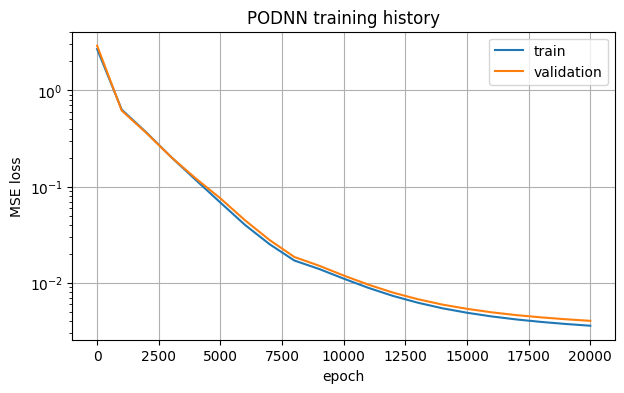

In [72]:
plt.figure(figsize=(7, 4))
plt.semilogy(history["epoch"], history["train_loss"], label="train")
plt.semilogy(history["epoch"], history["validation_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("PODNN training history")
plt.grid(True)
plt.legend()
plt.show()



## PODNN online prediction

Online evaluation is now only a neural-network forward pass plus reconstruction with the POD basis. No reduced Navier-Stokes solve is performed.


In [76]:
def predict_podnn_coefficients(mu0, mu1):
    mu = np.array([[mu0, mu1]], dtype=np.float32)
    mu_scaled = (mu - mu_mean) / mu_std
    x_test = torch.tensor(np.float32(mu_scaled))

    net.eval()
    with torch.no_grad():
        coeff_scaled = net(x_test).cpu().numpy()[0]

    coeff = coeff_scaled * coeff_scale + coeff_mean
    return coeff


def solve_podnn(mu0, mu1):
    coefficients = predict_podnn_coefficients(mu0, mu1)
    u_podnn = V_podnn @ coefficients

    u_x_podnn = u_podnn[0:speed_n_dofs]
    u_y_podnn = u_podnn[speed_n_dofs:2 * speed_n_dofs]
    p_podnn = u_podnn[2 * speed_n_dofs:]

    info = {
        "mu0": mu0,
        "mu1": mu1,
        "online_stage": "NN forward pass + POD reconstruction",
        "basis_dim": V_podnn.shape[1]
    }

    return u_podnn, u_x_podnn, u_y_podnn, p_podnn, coefficients, info


def compute_relative_errors(u_reference, u_approx):
    du = u_reference[:2 * speed_n_dofs] - u_approx[:2 * speed_n_dofs]
    u_ref = u_reference[:2 * speed_n_dofs]
    velocity_error = np.sqrt(du.T @ X_u @ du) / np.sqrt(u_ref.T @ X_u @ u_ref)

    dp = u_reference[2 * speed_n_dofs:] - u_approx[2 * speed_n_dofs:]
    p_ref = u_reference[2 * speed_n_dofs:]
    pressure_error = np.sqrt(dp.T @ X_p @ dp) / np.sqrt(p_ref.T @ X_p @ p_ref)

    dtotal = u_reference - u_approx
    total_error = np.sqrt(dtotal.T @ X_full @ dtotal) / np.sqrt(u_reference.T @ X_full @ u_reference)

    return total_error, velocity_error, pressure_error


In [77]:
test_points = [
    (0.1, 1.0),
    (0.1, 1.5),
    (0.1, 2.0),
    (0.1, 2.5),
    (0.1, 3.0),
]

for mu0_test, mu1_test in test_points:
    u_podnn, *_ = solve_podnn(mu0_test, mu1_test)
    u_fom, *_ = solve_fom(mu0_test, mu1_test)

    total_error, velocity_error, pressure_error = compute_relative_errors(u_fom, u_podnn)

    print(f"mu0={mu0_test}, mu1={mu1_test}")
    print("Total:", total_error)
    print("Velocity:", velocity_error)
    print("Pressure:", pressure_error)
    print()

mu0=0.1, mu1=1.0
Total: 0.062257939416610134
Velocity: 0.060371929105881295
Pressure: 0.11054879789167013

mu0=0.1, mu1=1.5
Total: 0.10148142462141924
Velocity: 0.09997157139902291
Pressure: 0.15811752217600306

mu0=0.1, mu1=2.0
Total: 0.14117984710675863
Velocity: 0.13950198859348634
Pressure: 0.2392440409217151

mu0=0.1, mu1=2.5
Total: 0.20513143226777183
Velocity: 0.2051008485320477
Pressure: 0.20733680956359266

mu0=0.1, mu1=3.0
Total: 0.25098682272544776
Velocity: 0.2514798357928449
Pressure: 0.2100140668732261



In [78]:
# Diagnostic: separate POD projection error from NN prediction error on validation snapshots.
# If projection error is small but PODNN error is large, the issue is the NN training.
validation_projection_errors = []
validation_podnn_errors = []

for idx in validation_indices.numpy():
    snapshot = snapshot_matrix[idx]
    projected_coeff = coefficient_matrix[idx]
    projected_solution = V_podnn @ projected_coeff

    mu0, mu1 = training_set[idx]
    podnn_solution, *_ = solve_podnn(mu0, mu1)

    projection_total_error, _, _ = compute_relative_errors(snapshot, projected_solution)
    podnn_total_error, _, _ = compute_relative_errors(snapshot, podnn_solution)

    validation_projection_errors.append(projection_total_error)
    validation_podnn_errors.append(podnn_total_error)

print("Mean validation POD projection error:", np.mean(validation_projection_errors))
print("Mean validation PODNN error on snapshots:", np.mean(validation_podnn_errors))


Mean validation POD projection error: 0.009854326430479425
Mean validation PODNN error on snapshots: 0.04808871076685574


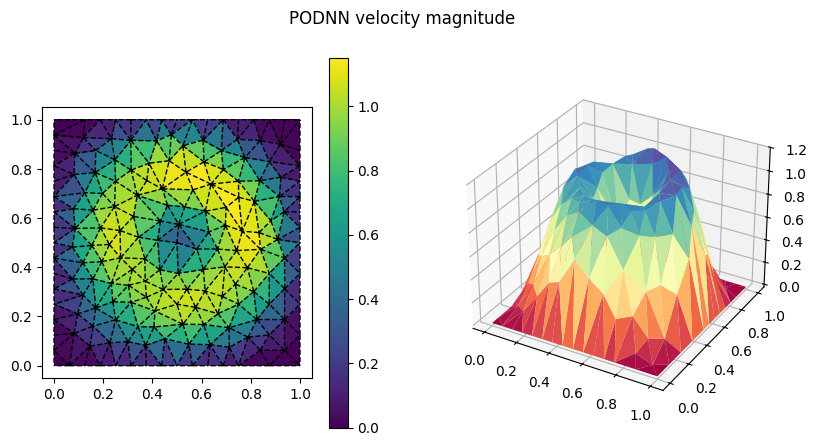

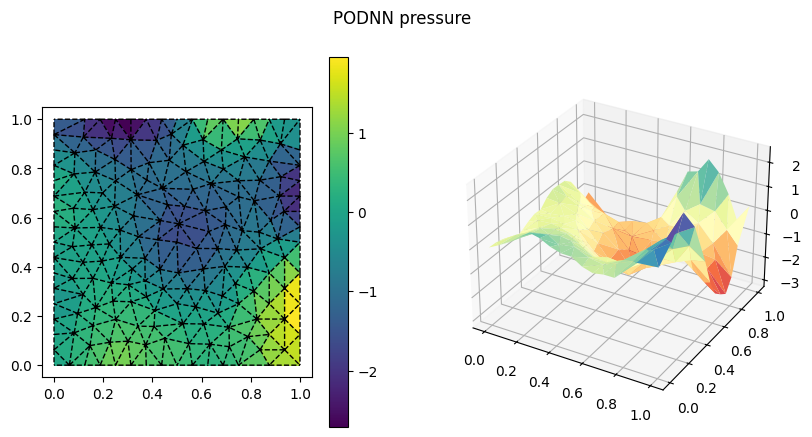

In [79]:
# Optional visualization of one predicted solution.
# We plot velocity magnitude and pressure at the mesh vertices.
velocity_magnitude_dofs = np.sqrt(u_x_podnn**2 + u_y_podnn**2)
zero_speed_strong = np.zeros(speed_n_strongs)
zero_pressure_strong = np.zeros(pressure_n_strongs)

velocity_on_vertices = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh,
    speed_dofs_data,
    velocity_magnitude_dofs,
    zero_speed_strong
)
pressure_on_vertices = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(
    mesh,
    pressure_dofs_data,
    p_podnn,
    zero_pressure_strong
)

other_ut.plot_solution(mesh, velocity_on_vertices.numeric_solution, title="PODNN velocity magnitude")
other_ut.plot_solution(mesh, pressure_on_vertices.numeric_solution, title="PODNN pressure")


## Error and speedup analysis

This mirrors the final comparison in `Q1.ipynb`, but the online reduced step is the neural network prediction instead of the POD-Galerkin Newton solve.


In [80]:
import time
import pandas as pd

mu0_values = np.linspace(0.1, 10.0, 5)
mu1_values = np.linspace(1.0, 3.0, 5)

results = []

for mu0 in mu0_values:
    for mu1 in mu1_values:
        print(f"Testing mu0={mu0:.2f}, mu1={mu1:.2f}")

        start = time.perf_counter()
        u_fom_full, ux_fom, uy_fom, p_fom, fom_info = solve_fom(mu0, mu1)
        fom_time = time.perf_counter() - start

        start = time.perf_counter()
        u_podnn_full, ux_podnn, uy_podnn, p_podnn, coeff_podnn, podnn_info = solve_podnn(mu0, mu1)
        podnn_time = time.perf_counter() - start

        total_error, velocity_error, pressure_error = compute_relative_errors(u_fom_full, u_podnn_full)
        speedup = fom_time / podnn_time

        results.append({
            "mu0": mu0,
            "mu1": mu1,
            "velocity_error": velocity_error,
            "pressure_error": pressure_error,
            "total_error": total_error,
            "fom_time": fom_time,
            "podnn_time": podnn_time,
            "speedup": speedup,
            "fom_iterations": fom_info["iterations"]
        })

df_results = pd.DataFrame(results)
df_results


Testing mu0=0.10, mu1=1.00
Testing mu0=0.10, mu1=1.50
Testing mu0=0.10, mu1=2.00
Testing mu0=0.10, mu1=2.50
Testing mu0=0.10, mu1=3.00
Testing mu0=2.58, mu1=1.00
Testing mu0=2.58, mu1=1.50
Testing mu0=2.58, mu1=2.00
Testing mu0=2.58, mu1=2.50
Testing mu0=2.58, mu1=3.00
Testing mu0=5.05, mu1=1.00
Testing mu0=5.05, mu1=1.50
Testing mu0=5.05, mu1=2.00
Testing mu0=5.05, mu1=2.50
Testing mu0=5.05, mu1=3.00
Testing mu0=7.53, mu1=1.00
Testing mu0=7.53, mu1=1.50
Testing mu0=7.53, mu1=2.00
Testing mu0=7.53, mu1=2.50
Testing mu0=7.53, mu1=3.00
Testing mu0=10.00, mu1=1.00
Testing mu0=10.00, mu1=1.50
Testing mu0=10.00, mu1=2.00
Testing mu0=10.00, mu1=2.50
Testing mu0=10.00, mu1=3.00


,mu0,mu1,velocity_error,pressure_error,total_error,fom_time,podnn_time,speedup,fom_iterations
0,0.100,1.0,0.060372,0.110549,0.062258,0.290673,0.000761,382.170036,4
1,0.100,1.5,0.099972,0.158118,0.101481,0.290100,0.000657,441.317351,4
2,0.100,2.0,0.139502,0.239244,0.141180,0.290491,0.000705,412.119198,4
3,0.100,2.5,0.205101,0.207337,0.205131,0.299013,0.000673,444.465860,4
4,0.100,3.0,0.251480,0.210014,0.250987,0.290916,0.000773,376.528087,4
5,2.575,1.0,0.053064,0.015903,0.021358,0.236188,0.000769,307.031763,3
6,2.575,1.5,0.034162,0.018198,0.022449,0.232925,0.000818,284.643516,3
7,2.575,2.0,0.029356,0.026437,0.028571,0.230960,0.000620,372.597937,3
8,2.575,2.5,0.041442,0.012626,0.018542,0.129591,0.000524,247.455798,3
9,2.575,3.0,0.042334,0.015052,0.019108,0.134675,0.000511,263.725664,3


In [81]:
print("Average total error:", df_results["total_error"].mean())
print("Average velocity error:", df_results["velocity_error"].mean())
print("Average pressure error:", df_results["pressure_error"].mean())
print("Average speedup:", df_results["speedup"].mean())


Average total error: 0.04835786831525623
Average velocity error: 0.09588662598283167
Average pressure error: 0.05105553453260094
Average speedup: 285.2720109908312


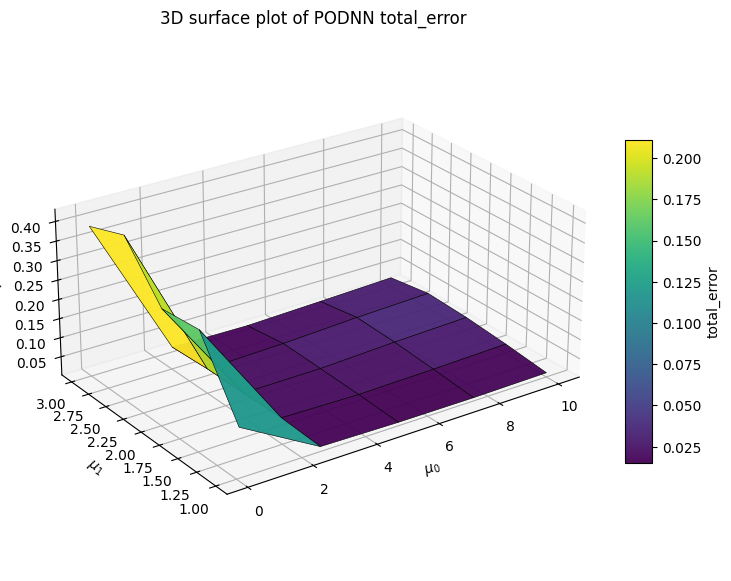

In [44]:
# Choose what you want to plot on the z-axis.
plot_quantity = "total_error"
# plot_quantity = "velocity_error"
# plot_quantity = "pressure_error"
# plot_quantity = "speedup"

mu0_grid = np.sort(df_results["mu0"].unique())
mu1_grid = np.sort(df_results["mu1"].unique())
MU0, MU1 = np.meshgrid(mu0_grid, mu1_grid, indexing="ij")

Z = df_results.pivot(
    index="mu0",
    columns="mu1",
    values=plot_quantity
).values

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    MU0,
    MU1,
    Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.4,
    antialiased=True,
    alpha=0.95
)

ax.set_xlabel(r"$\mu_0$")
ax.set_ylabel(r"$\mu_1$")
ax.set_zlabel(plot_quantity)
ax.set_title(f"3D surface plot of PODNN {plot_quantity}")
ax.view_init(elev=25, azim=-125)
ax.set_box_aspect((1.4, 1.0, 0.6))
fig.colorbar(surface, ax=ax, shrink=0.6, aspect=12, label=plot_quantity)

plt.show()
